In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score  # Use MAE instead of MAPE
from sklearn.model_selection import KFold
from tensorflow.keras.layers import Input, Conv1D, Activation, Add, GRU, Dense, Multiply, Softmax, LayerNormalization, Concatenate, Lambda, Dropout, Flatten, GlobalAveragePooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import tensorflow as tf
from constants import CALCEDatasetConstants, ModelOutputConstants, NASADatasetConstants
from preprocessing_functions import generate_sliding_window_data
import pandas as pd
from sklearn.model_selection import train_test_split

In [18]:
class CustomDataset(tf.data.Dataset):
    def __new__(cls, x, y):
        return tf.data.Dataset.from_tensor_slices((x, y))

def generate_dataset(X, Y, batch_size=32, shuffle=True):
    dataset = CustomDataset(X, Y)
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(Y))
    dataset = dataset.batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)
    return dataset

In [19]:
TRAIN_RATIO = 0.8
VAL_RATIO = 1 - TRAIN_RATIO

## NASA Dataset

In [20]:
nasa_dfs = {NASADatasetConstants.BATTERY_NAMES.value[i]: \
       pd.read_csv(NASADatasetConstants.BATTERY_FILEPATHS.value[i]) for i in range(len(NASADatasetConstants.BATTERY_NAMES.value))}
nasa_dfs

{'B0005':      cycle  amb_temp              date_time  voltage_battery  current_battery  \
 0        1        24  02 Apr 2008, 15:25:41         3.277170        -0.006528   
 1        3        24  02 Apr 2008, 19:43:48         3.300245        -0.000448   
 2        5        24  03 Apr 2008, 00:01:06         3.327451         0.001026   
 3        7        24  03 Apr 2008, 04:16:37         3.314182        -0.002234   
 4        9        24  03 Apr 2008, 08:33:25         3.305497         0.000009   
 ..     ...       ...                    ...              ...              ...   
 163    599        24  26 May 2008, 10:44:38         3.615561        -0.002548   
 164    603        24  26 May 2008, 15:30:43         3.621191        -0.002460   
 165    607        24  26 May 2008, 20:21:04         3.619185         0.000478   
 166    611        24  27 May 2008, 15:52:41         3.595365        -0.002342   
 167    613        24  27 May 2008, 20:45:42         3.589937        -0.000583   
 
     

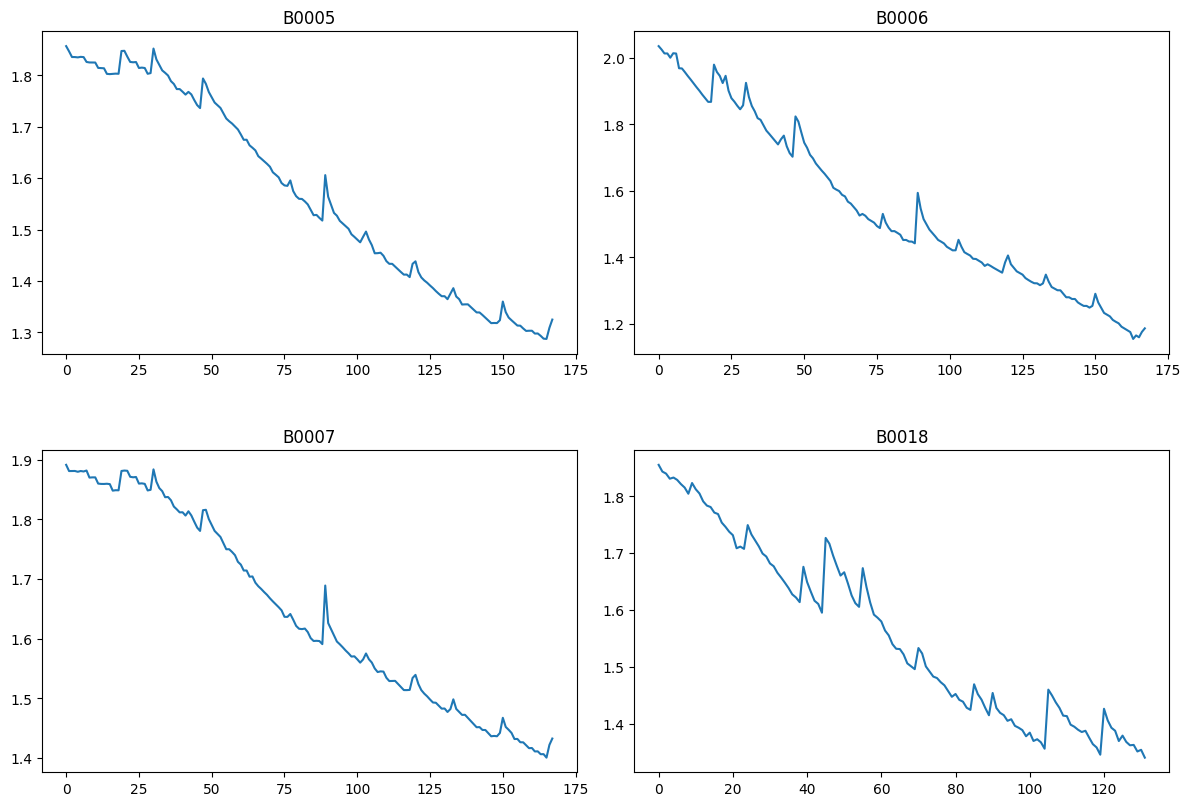

In [21]:
fig, ax = plt.subplots(nrows=int(len(nasa_dfs)/2), ncols=2, figsize=(12, 8))
fig.tight_layout()
plt.subplots_adjust(hspace=0.3)

for i, (battery_number, df) in enumerate(nasa_dfs.items()):
    ax[int(i/2), i%2].plot(df.index, df['capacity'])
    ax[int(i/2), i%2].set_title(f'{battery_number}')

plt.show()

In [22]:
# Create a list containing test and training battery numbers for each case
test_and_trains = []

for battery_name in NASADatasetConstants.BATTERY_NAMES.value:
    excluded_list = [x for x in NASADatasetConstants.BATTERY_NAMES.value if x != battery_name]
    test_and_trains.append((battery_name, excluded_list))

test_and_trains

[('B0005', ['B0006', 'B0007', 'B0018']),
 ('B0006', ['B0005', 'B0007', 'B0018']),
 ('B0007', ['B0005', 'B0006', 'B0018']),
 ('B0018', ['B0005', 'B0006', 'B0007'])]

In [23]:
NASA_train_datasets = []
NASA_val_datasets = []
NASA_test_datasets = []

for test_battery, training_batteries in test_and_trains:
    trainX, trainY = [], []
    
    for battery in training_batteries:
        x, y = generate_sliding_window_data(nasa_dfs[battery]['capacity'], window_size=5)
        trainX.extend(x)
        trainY.extend(y)
    
    trainX, trainY = np.array(trainX), np.array(trainY)
    testX, testY = generate_sliding_window_data(nasa_dfs[test_battery]['capacity'], window_size=5)
    testX, testY = np.array(testX), np.array(testY)
    
    # Split training data into train and validation sets
    trainX_split, valX_split, trainY_split, valY_split = train_test_split(trainX, trainY, test_size=VAL_RATIO, shuffle=True)
    
    train_dataset = generate_dataset(trainX_split, trainY_split)
    val_dataset = generate_dataset(valX_split, valY_split, shuffle=False)
    test_dataset = generate_dataset(testX, testY, shuffle=False)
    
    NASA_train_datasets.append(train_dataset)
    NASA_val_datasets.append(val_dataset)
    NASA_test_datasets.append(test_dataset)

In [24]:
trainX.shape, trainY.shape

((489, 5), (489,))

In [25]:
# 🚀 Train Model Function
def train_model(model, train_dataset, val_dataset, optimizer, criterion, min_val, diff_val, epochs, save_path):
    """
    Trains a TCN-GRU-DNN model on the given dataset with input normalization.

    Args:
        model (tf.keras.Model): The model to train.
        train_dataset (tf.data.Dataset): Training dataset.
        val_dataset (tf.data.Dataset): Validation dataset.
        optimizer (tf.keras.optimizers.Optimizer): Optimizer for training.
        criterion (str): Loss function name.
        min_val (float): Minimum value used for normalization.
        diff_val (float): Range (difference) used for normalization.
        epochs (int): Number of epochs to train.
        save_path (str): Path to save the best model.

    Returns:
        None
    """
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # Normalize dataset
    def normalize(features, labels):
        features = (features - min_val) / diff_val
        labels = (labels - min_val) / diff_val
        return features, labels

    train_dataset = train_dataset.map(normalize)
    val_dataset = val_dataset.map(normalize)

    # Compile Model
    model.compile(optimizer=optimizer, loss=criterion)

    # Callbacks
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=50, restore_best_weights=True),
        ModelCheckpoint(filepath=save_path, monitor="val_loss", save_best_only=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6),
    ]

    # Train Model
    model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=epochs,
        callbacks=callbacks
    )

# 🚀 Evaluation Function
def evaluate_model(model, test_dataset, min_val, diff_val):
    """
    Evaluates the model on test dataset.
    """
    y_true, y_pred = [], []

    for X_batch, y_batch in test_dataset:
        # Normalize inputs and targets
        X_batch = (X_batch - min_val) / diff_val  
        y_batch = (y_batch - min_val) / diff_val  # Normalize y_batch too!

        preds = model.predict(X_batch)  # Model expects normalized input
        y_true.append(y_batch.numpy())  
        y_pred.append(preds)

    
    y_true = np.concatenate(y_true, axis=0).reshape(-1) * diff_val + min_val
    y_pred = np.concatenate(y_pred, axis=0).reshape(-1) * diff_val + min_val

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    return {"RMSE": rmse, "MAE": mae}

# 🚀 Plot Predictions Function
def plot_predictions(
    model, 
    dfs, 
    test_battery, 
    generate_sliding_window_data, 
    min_val, 
    diff_val, 
    column_name="Discharge_Capacity(Ah)", 
    cutoff_percentage=30, 
    window_size=10
):
    """
    Generates predictions for the test curve using the given TensorFlow model and plots the results.

    Args:
        model (tf.keras.Model): Trained TensorFlow model for predictions.
        dfs (dict): Dictionary containing battery dataframes.
        test_battery (str): Key for the battery data in the dfs dictionary.
        generate_sliding_window_data (callable): Function to generate sliding window data.
        min_val (float): Minimum value used for normalization.
        diff_val (float): Range (difference) used for normalization.
        column_name (str, optional): Name of the column for discharge capacity. Defaults to "Discharge_Capacity(Ah)".
        cutoff_percentage (int, optional): Percentage to determine the cutoff cycle. Defaults to 30.
        window_size (int, optional): Window size for the sliding window. Defaults to 10.

    Returns:
        None
    """
    # Determine cutoff cycle based on percentage
    cutoff_cycle = int(cutoff_percentage * dfs[test_battery].shape[0] / 100)

    # Split initial and test curves
    initial = dfs[test_battery].loc[:cutoff_cycle, column_name].values
    test_curve = dfs[test_battery].loc[cutoff_cycle:, column_name].values

    # Generate sliding window data
    sliding_windows = generate_sliding_window_data(np.append(initial[-window_size:], test_curve), window_size)[0]

    # Normalize sliding window data
    sliding_windows_scaled = (sliding_windows - min_val) / diff_val

    # Generate predictions using TensorFlow model
    predictions = model.predict(sliding_windows_scaled)
    
    # Denormalize predictions
    predictions = predictions * diff_val + min_val
    predictions = predictions.flatten()

    # Cycle indices for plotting
    cycle_indices = np.arange(1, initial.shape[0] + test_curve.shape[0] + 1)
    cycle_indices_before = cycle_indices[:cutoff_cycle + 1]
    cycle_indices_after = cycle_indices[cutoff_cycle + 1:]

    # Plot results
    plt.figure(figsize=(10, 6))
    plt.plot(cycle_indices_before, initial[:cutoff_cycle + 1], label="Initial Data", color="blue")
    plt.plot(cycle_indices_after, test_curve, label="True Test Curve", color="green")
    plt.plot(cycle_indices_after, predictions, label="Predictions", color="red", linestyle="--")
    plt.xlabel("Cycle Index")
    plt.ylabel(column_name)
    plt.title(f"Predicted vs Actual {column_name}")
    plt.legend()
    plt.grid()
    plt.show()

In [26]:
# Define a TCN block with dilations and attention
def dilated_tcn_block(input_layer, nb_filters, kernel_size, dilation_rate):
    conv1 = Conv1D(filters=nb_filters, kernel_size=kernel_size, padding='causal', dilation_rate=dilation_rate)(input_layer)
    conv1 = Activation('relu')(conv1)
    return conv1

# Attention mechanism
def attention_layer(input_layer, input_dim):
    query = Dense(input_dim)(input_layer)
    key = Dense(input_dim)(input_layer)
    attention_scores = Multiply()([query, key])
    attention_scores = Activation('sigmoid')(attention_scores)  # Use sigmoid activation
    attention_output = Multiply()([input_layer, attention_scores])
    return attention_output

# Dynamic Weight Adaptation
def dynamic_weight_adaptation(input_layer):
    weight = Dense(1, activation='sigmoid')(input_layer)
    adapted_output = Multiply()([input_layer, weight])
    return adapted_output

In [27]:
# Define model inputs
input_layer = Input(shape=(trainX.shape[1], 1))
input_dim = 1

# Define Multi-Head TCN parameters
num_heads = 3  # Number of heads
dilation_rates = [1, 2, 4]  # Dilation rates for TCN blocks
tcn_blocks = []

for head in range(num_heads):
    attention_output = attention_layer(input_layer, input_dim)
    tcn_branch = []
    for dilation_rate in dilation_rates:
        tcn_block = dilated_tcn_block(attention_output, nb_filters=32, kernel_size=3, dilation_rate=dilation_rate)
        tcn_branch.append(tcn_block)
    merged_branch = Add()(tcn_branch)
    adapted_branch = dynamic_weight_adaptation(merged_branch)
    residual_output = Add()([adapted_branch, input_layer])
    tcn_blocks.append(residual_output)

# Concatenate the outputs of all TCN branches
merged = Concatenate()(tcn_blocks)
normalized_output = LayerNormalization()(merged)

# Add GRU and dense layers
gru_layer = GRU(64, activation='relu', return_sequences=False)(normalized_output)
dense1 = Dense(32, activation='relu', kernel_regularizer=l2(0.001))(gru_layer)
dense2 = Dense(16, activation='relu', kernel_regularizer=l2(0.001))(dense1)
output_layer = Dense(1, activation='linear', kernel_regularizer=l2(0.001))(dense2)

In [28]:
MIN = 0.0
MAX = 2.0
DIFF = MAX - MIN


🚀 Training on NASA Dataset 1...

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 217ms/step - loss: 0.0025 - val_loss: 0.0022 - learning_rate: 2.0000e-04
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0023 - val_loss: 0.0022 - learning_rate: 2.0000e-04
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0023 - val_loss: 0.0022 - learning_rate: 2.0000e-04
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0023 - val_loss: 0.0022 - learning_rate: 2.0000e-04
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0023 - val_loss: 0.0022 - learning_rate: 2.0000e-04
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0022 - val_loss: 0.0022 - learning_rate: 2.0000e-04
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0022 - val_loss: 0.0022 - learning_rate: 1.0000e-04
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0022 - val_loss: 0.0022 - learning_rate: 1.0000e-04
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0

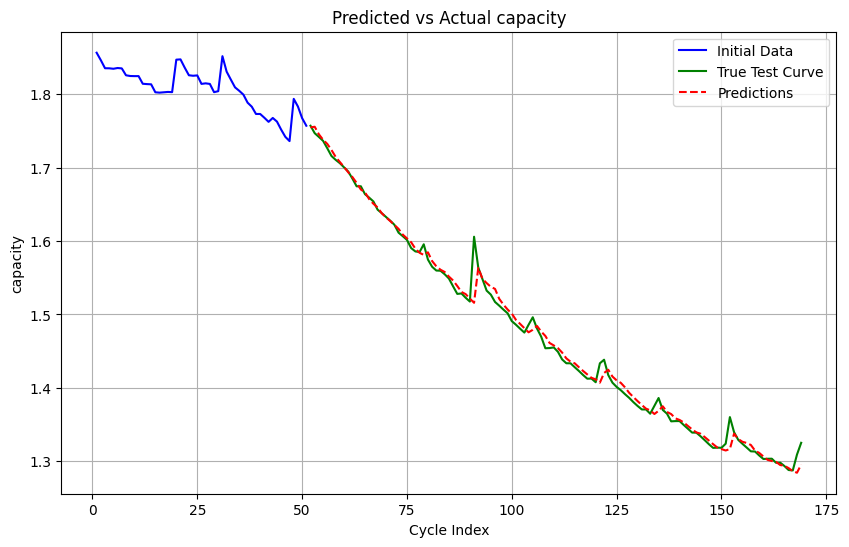


🚀 Training on NASA Dataset 2...

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 232ms/step - loss: 0.0023 - val_loss: 0.0022 - learning_rate: 2.0000e-04
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0022 - val_loss: 0.0022 - learning_rate: 2.0000e-04
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0021 - val_loss: 0.0021 - learning_rate: 2.0000e-04
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0021 - val_loss: 0.0021 - learning_rate: 2.0000e-04
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0021 - val_loss: 0.0021 - learning_rate: 2.0000e-04
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0021 - val_loss: 0.0021 - learning_rate: 2.0000e-04
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0020 - val_loss: 0.0021 - learning_rate: 1.0000e-04
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0021 - val_loss: 0.0021 - learning_rate: 1.0000e-04
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0

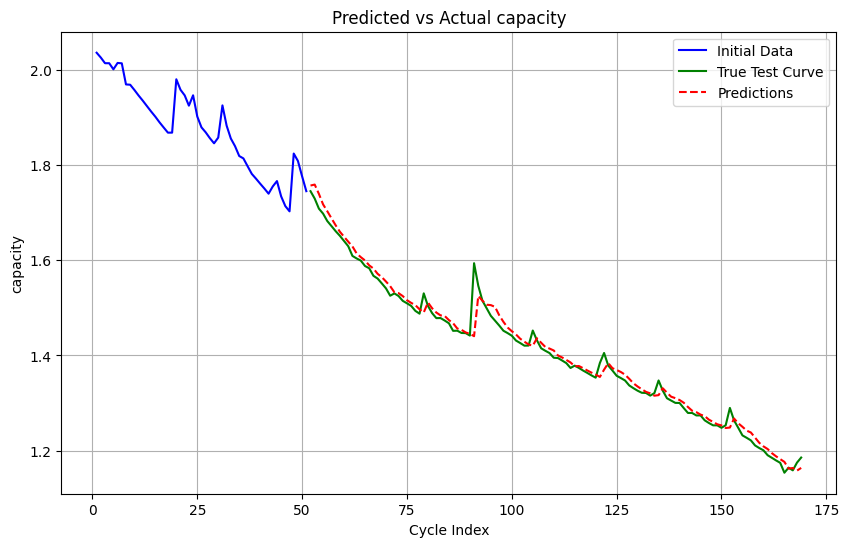


🚀 Training on NASA Dataset 3...

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 230ms/step - loss: 0.0022 - val_loss: 0.0020 - learning_rate: 2.0000e-04
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0021 - val_loss: 0.0020 - learning_rate: 2.0000e-04
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0020 - val_loss: 0.0020 - learning_rate: 2.0000e-04
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0020 - val_loss: 0.0020 - learning_rate: 2.0000e-04
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0020 - val_loss: 0.0020 - learning_rate: 2.0000e-04
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0020 - val_loss: 0.0020 - learning_rate: 2.0000e-04
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0020 - val_loss: 0.0020 - learning_rate: 1.0000e-04
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0020 - val_loss: 0.0019 - learning_rate: 1.0000e-04
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0

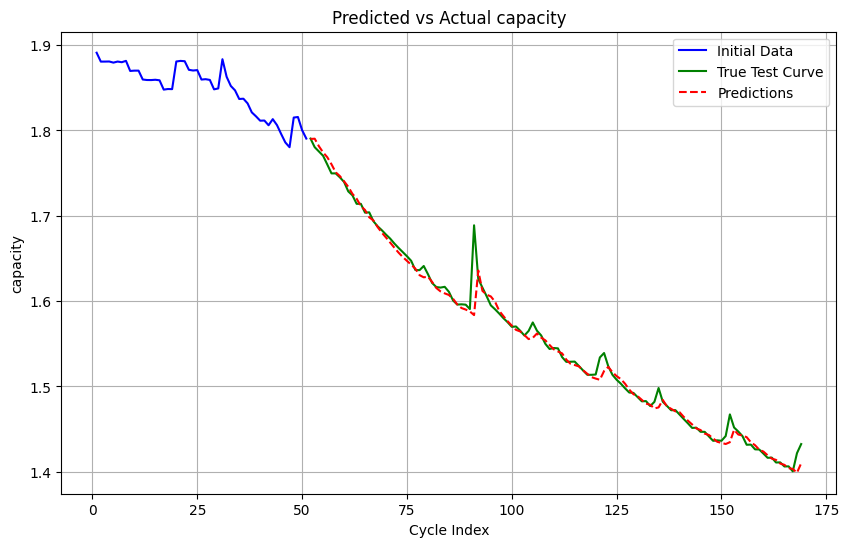


🚀 Training on NASA Dataset 4...

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 175ms/step - loss: 0.0021 - val_loss: 0.0020 - learning_rate: 2.0000e-04
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0019 - val_loss: 0.0019 - learning_rate: 2.0000e-04
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0019 - val_loss: 0.0019 - learning_rate: 2.0000e-04
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0019 - val_loss: 0.0019 - learning_rate: 2.0000e-04
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0019 - val_loss: 0.0019 - learning_rate: 2.0000e-04
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0019 - val_loss: 0.0019 - learning_rate: 2.0000e-04
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0018 - val_loss: 0.0018 - learning_rate: 2.0000e-04
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0019 - val_loss: 0.0018 - learning_rate: 2.0000e-04
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0

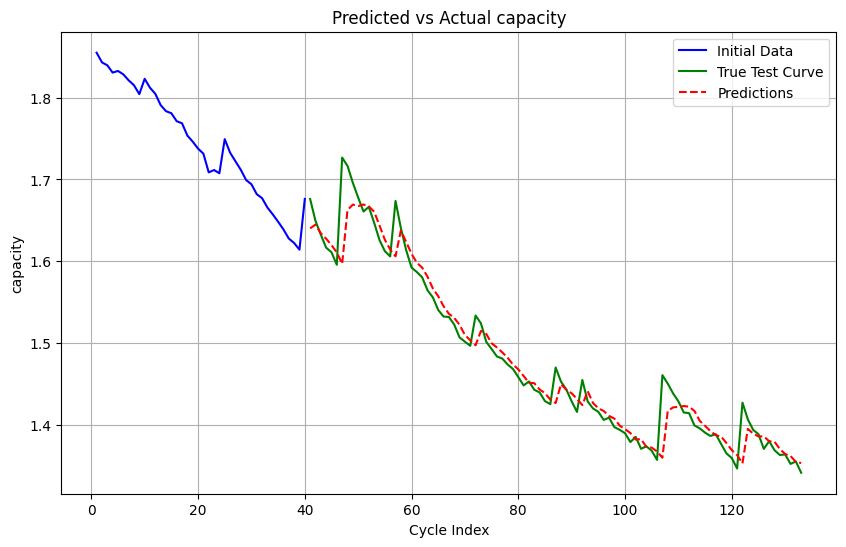

In [31]:
# 📌 Model Training Loop (TensorFlow Equivalent)
for i in range(4):
    print(f"\n🚀 Training on NASA Dataset {i+1}...\n")
    model = Model(inputs=input_layer, outputs=output_layer)
    # Optimizer & Loss
    optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4)
    criterion = "mean_squared_error"

    # Train Model
    save_path = ModelOutputConstants.NASA_OUTPUT_PATH.value / f'tf_model_1_{test_and_trains[i][0]}.keras'
    train_model(
        model=model,
        train_dataset=NASA_train_datasets[i],  # TensorFlow dataset
        val_dataset=NASA_val_datasets[i],
        optimizer=optimizer,
        criterion=criterion,
        min_val=MIN,
        diff_val=DIFF,
        epochs=50,
        save_path=save_path
    )

    # Load Best Model
    model.load_weights(save_path)

    # Evaluate Model
    metrics = evaluate_model(model, NASA_test_datasets[i], MIN, DIFF)
    print(f'🚀 RMSE: {metrics["RMSE"]:}, MAE: {metrics["MAE"]:}')

    # Plot Predictions
    plot_predictions(model, nasa_dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, 'capacity', 30, 5)


In [40]:
# Fourier Transform-based feature embedding
def fourier_embedding(input_layer):
    return Lambda(lambda x: tf.abs(tf.signal.fft(tf.cast(x, tf.complex64))))(input_layer)

# Learnable Gated Dilation Mechanism
def gated_dilated_tcn(input_layer, nb_filters, kernel_size):
    dilation_rates = [1, 2, 4]
    branches = []
    for rate in dilation_rates:
        gate = Dense(1, activation='sigmoid')(input_layer)
        conv = Conv1D(filters=nb_filters, kernel_size=kernel_size, padding='causal', dilation_rate=rate)(input_layer)
        gated_conv = Multiply()([conv, gate])
        branches.append(gated_conv)
    return Add()(branches)

# Dual Attention Mechanism (Temporal + Spatial)
def dual_attention(input_layer, input_dim):
    query = Dense(input_dim)(input_layer)
    key = Dense(input_dim)(input_layer)
    value = Dense(input_dim)(input_layer)
    attention_scores = Lambda(lambda x: tf.matmul(x[0], x[1], transpose_b=True))([query, key])
    attention_weights = Softmax()(attention_scores)
    spatial_attention = Multiply()([value, attention_weights])
    temporal_attention = Conv1D(filters=input_dim, kernel_size=1, activation='sigmoid')(input_layer)
    return Multiply()([spatial_attention, temporal_attention])

# Uncertainty-Aware MC Dropout
def mc_dropout(rate=0.2):
    return Dropout(rate)

def build_model(input_shape):
    input_layer = Input(shape=input_shape)
    embedded_features = fourier_embedding(input_layer)
    attention_output = dual_attention(embedded_features, input_shape[-1])
    tcn_output = gated_dilated_tcn(attention_output, nb_filters=32, kernel_size=3)
    norm_output = LayerNormalization()(tcn_output)
   
    # Memory-Augmented GRU
    gru_layer = GRU(64, activation='relu', return_sequences=True)(norm_output)
    memory_gate = Dense(64, activation='sigmoid')(gru_layer)
    memory_output = Multiply()([gru_layer, memory_gate])
   
    flattened_output = Flatten()(memory_output) # <---- Added Flatten Layer

    # Dense layers with MC Dropout
    dense1 = Dense(32, activation='relu', kernel_regularizer=l2(0.001))(flattened_output)
    dropout1 = mc_dropout()(dense1)
    dense2 = Dense(16, activation='relu', kernel_regularizer=l2(0.001))(dropout1)
    dropout2 = mc_dropout()(dense2)
    output_layer = Dense(1, activation='linear')(dropout2)
   
    model = Model(inputs=input_layer, outputs=output_layer)
    return model


🚀 Training on NASA Dataset B0005...

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 169ms/step - loss: 0.3295 - val_loss: 0.1270 - learning_rate: 0.0020
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.1429 - val_loss: 0.0828 - learning_rate: 0.0020
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1118 - val_loss: 0.0402 - learning_rate: 0.0020
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0816 - val_loss: 0.0391 - learning_rate: 0.0020
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0703 - val_loss: 0.0309 - learning_rate: 0.0020
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0666 - val_loss: 0.0286 - learning_rate: 0.0020
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0556 - val_loss: 0.0299 - learning_rate: 0.0020
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0507 - val_loss: 0.0221 - learning_rate: 0.0020
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0532 - val_loss: 0

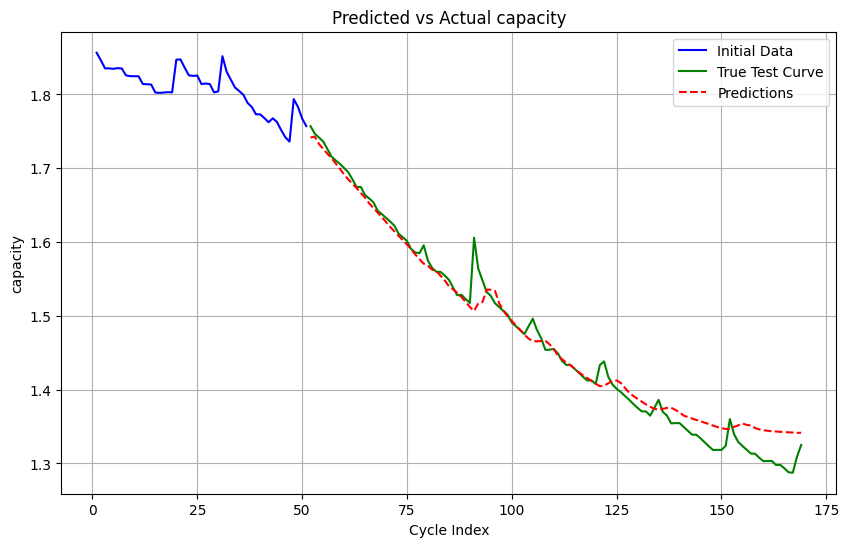


🚀 Training on NASA Dataset B0006...

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 190ms/step - loss: 0.3297 - val_loss: 0.0838 - learning_rate: 0.0020
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1204 - val_loss: 0.0576 - learning_rate: 0.0020
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0898 - val_loss: 0.0429 - learning_rate: 0.0020
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0837 - val_loss: 0.0382 - learning_rate: 0.0020
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0744 - val_loss: 0.0380 - learning_rate: 0.0020
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0758 - val_loss: 0.0316 - learning_rate: 0.0020
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0654 - val_loss: 0.0350 - learning_rate: 0.0020
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0566 - val_loss: 0.0331 - learning_rate: 0.0020
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0584 - val_loss: 0

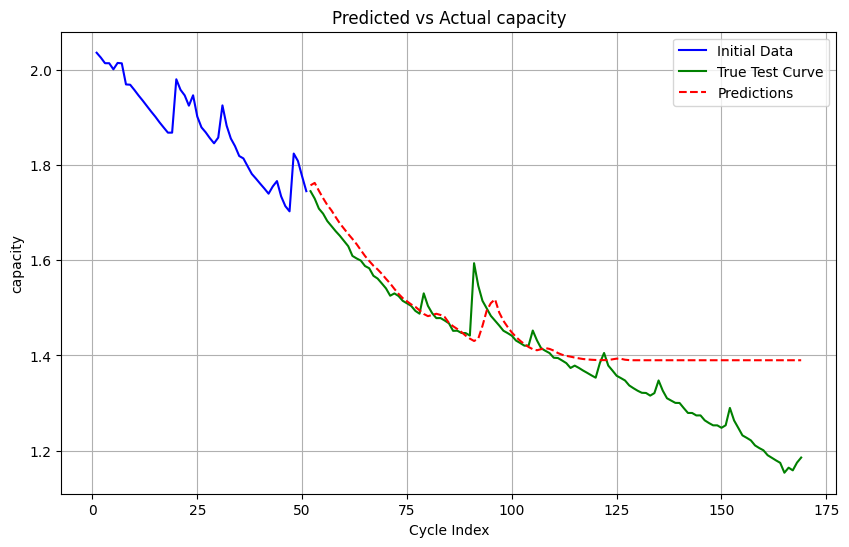


🚀 Training on NASA Dataset B0007...

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 167ms/step - loss: 0.4284 - val_loss: 0.1192 - learning_rate: 0.0020
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.1469 - val_loss: 0.0561 - learning_rate: 0.0020
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.1005 - val_loss: 0.0470 - learning_rate: 0.0020
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0933 - val_loss: 0.0458 - learning_rate: 0.0020
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0891 - val_loss: 0.0378 - learning_rate: 0.0020
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0749 - val_loss: 0.0436 - learning_rate: 0.0020
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0732 - val_loss: 0.0521 - learning_rate: 0.0020
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0715 - val_loss: 0.0460 - learning_rate: 0.0020
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0610 - val_loss: 0

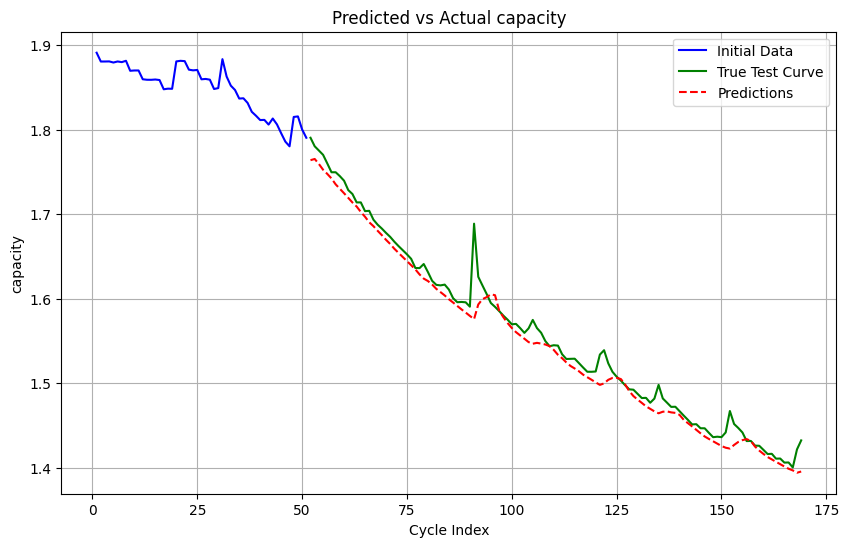


🚀 Training on NASA Dataset B0018...

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 145ms/step - loss: 0.4422 - val_loss: 0.1063 - learning_rate: 0.0020
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.2006 - val_loss: 0.0485 - learning_rate: 0.0020
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1304 - val_loss: 0.0487 - learning_rate: 0.0020
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.1127 - val_loss: 0.0397 - learning_rate: 0.0020
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0932 - val_loss: 0.0358 - learning_rate: 0.0020
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0839 - val_loss: 0.0399 - learning_rate: 0.0020
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0811 - val_loss: 0.0410 - learning_rate: 0.0020
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0814 - val_loss: 0.0291 - learning_rate: 0.0020
Epoch 9/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0619 - val_loss: 0

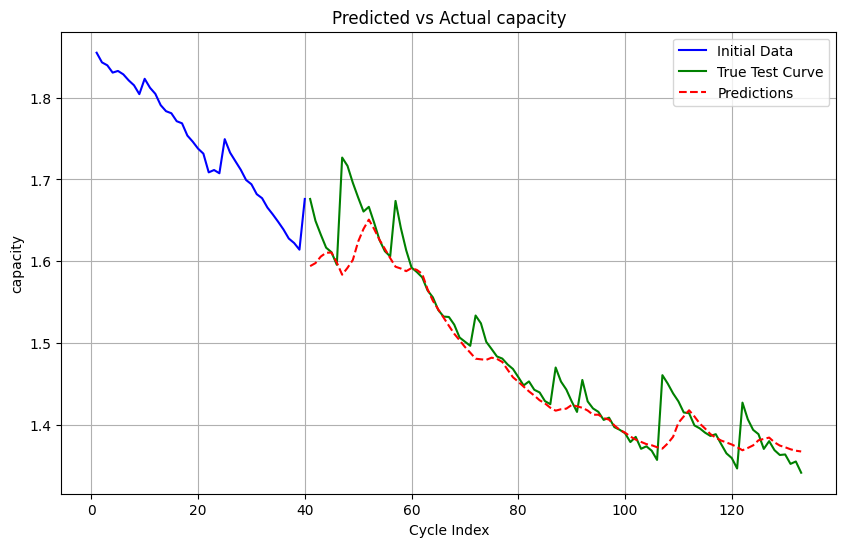

In [41]:
# 📌 Model Training Loop (TensorFlow Equivalent)
for i in range(4):
    print(f"\n🚀 Training on NASA Dataset {test_and_trains[i][0]}...\n")
    input_shape = (trainX.shape[1], 1) 
    model = build_model(input_shape)
    # Optimizer & Loss
    optimizer = tf.keras.optimizers.Adam(learning_rate=2e-3)
    criterion = "mean_squared_error"

    # Train Model
    save_path = ModelOutputConstants.NASA_OUTPUT_PATH.value / f'tf_model_2_{test_and_trains[i][0]}.keras'
    train_model(
        model=model,
        train_dataset=NASA_train_datasets[i],  # TensorFlow dataset
        val_dataset=NASA_val_datasets[i],
        optimizer=optimizer,
        criterion=criterion,
        min_val=MIN,
        diff_val=DIFF,
        epochs=200,
        save_path=save_path
    )

    # Load Best Model
    model.load_weights(save_path)

    # Evaluate Model
    metrics = evaluate_model(model, NASA_test_datasets[i], MIN, DIFF)
    print(f'🚀 RMSE: {metrics["RMSE"]:}, MAE: {metrics["MAE"]:}')

    # Plot Predictions
    plot_predictions(model, nasa_dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, 'capacity', 30, 5)


## CALCE Dataset

In [6]:
PROCESSED_BATTERY_PATHS = [CALCEDatasetConstants.BATTERY_PROCESSED_PATH.value / (battery_name+'.csv') for battery_name in CALCEDatasetConstants.BATTERY_NAMES.value]
dfs = {CALCEDatasetConstants.BATTERY_NUMBERS.value[i]: \
       pd.read_csv(PROCESSED_BATTERY_PATHS[i]).drop(['Unnamed: 0'], axis=1) for i in range(len(CALCEDatasetConstants.BATTERY_NUMBERS.value))}
dfs

{35:      Cycle_Index  Discharge_Capacity(Ah)
 0              1                1.123221
 1              2                1.111035
 2              3                1.106058
 3              4                1.102627
 4              5                1.098143
 ..           ...                     ...
 757          758                0.332357
 758          759                0.328566
 759          760                0.325232
 760          761                0.322707
 761          762                0.319955
 
 [762 rows x 2 columns],
 36:      Cycle_Index  Discharge_Capacity(Ah)
 0              1                1.134613
 1              2                1.124949
 2              3                1.121679
 3              4                1.119217
 4              5                1.115648
 ..           ...                     ...
 768          769                0.173019
 769          770                0.169924
 770          771                0.168700
 771          772                0.168793

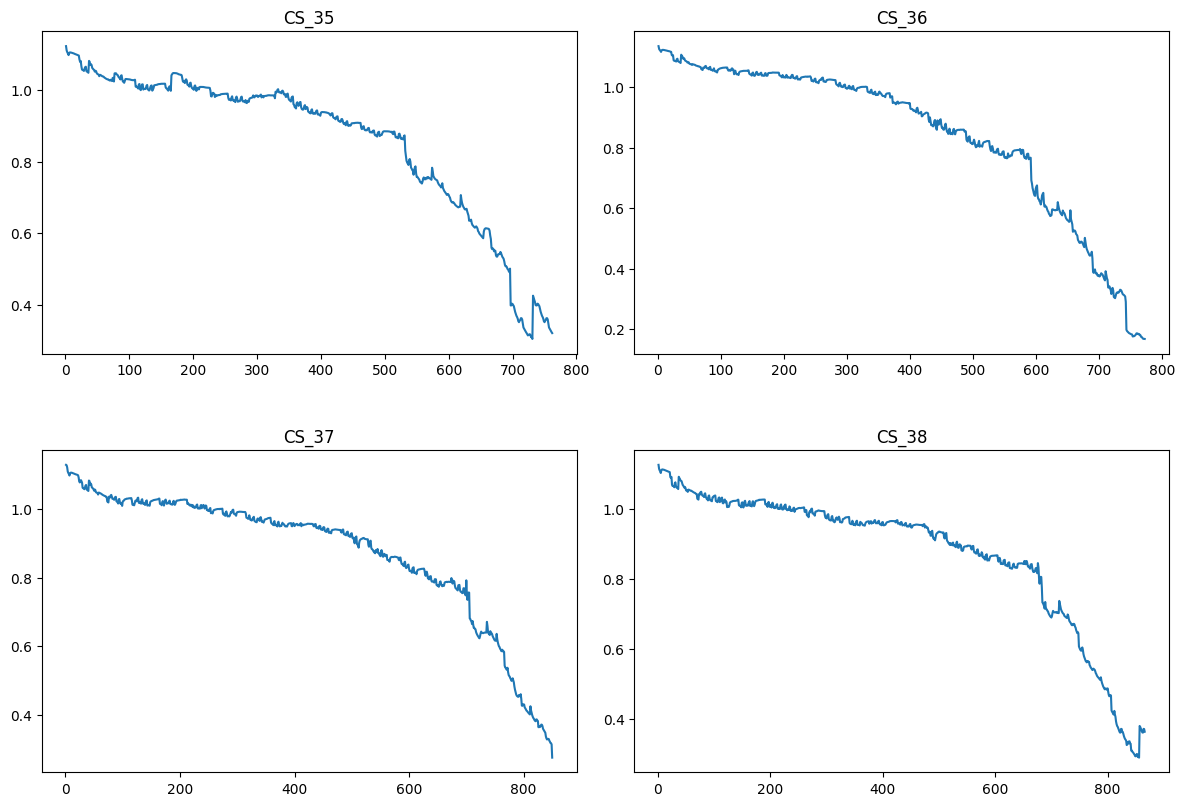

In [7]:
fig, ax = plt.subplots(nrows=int(len(dfs)/2), ncols=2, figsize=(12, 8))
fig.tight_layout()
plt.subplots_adjust(hspace=0.3)

for i, (battery_number, df) in enumerate(dfs.items()):
    ax[int(i/2), i%2].plot(df['Cycle_Index'], df['Discharge_Capacity(Ah)'])
    ax[int(i/2), i%2].set_title(f'CS_{battery_number}')

plt.show()

In [8]:
# Create a list containing test and training battery numbers for each case
test_and_trains = []

for battery_name in CALCEDatasetConstants.BATTERY_NUMBERS.value:
    excluded_list = [x for x in CALCEDatasetConstants.BATTERY_NUMBERS.value if x != battery_name]
    test_and_trains.append((battery_name, excluded_list))

test_and_trains

[(35, [36, 37, 38]),
 (36, [35, 37, 38]),
 (37, [35, 36, 38]),
 (38, [35, 36, 37])]

In [14]:
CALCE_train_datasets = []
CALCE_val_datasets = []
CALCE_test_datasets = []

for test_battery, training_batteries in test_and_trains:
    trainX, trainY = [], []
    
    for battery in training_batteries:
        x, y = generate_sliding_window_data(dfs[battery]['Discharge_Capacity(Ah)'], window_size=10)
        trainX.extend(x)
        trainY.extend(y)
    
    trainX, trainY = np.array(trainX), np.array(trainY)
    testX, testY = generate_sliding_window_data(dfs[test_battery]['Discharge_Capacity(Ah)'], window_size=10)
    testX, testY = np.array(testX), np.array(testY)
    
    # Split training data into train and validation sets
    trainX_split, valX_split, trainY_split, valY_split = train_test_split(trainX, trainY, test_size=VAL_RATIO, shuffle=True)
    
    train_dataset = generate_dataset(trainX_split, trainY_split)
    val_dataset = generate_dataset(valX_split, valY_split, shuffle=False)
    test_dataset = generate_dataset(testX, testY, shuffle=False)
    
    CALCE_train_datasets.append(train_dataset)
    CALCE_val_datasets.append(val_dataset)
    CALCE_test_datasets.append(test_dataset)

In [15]:
MIN = 0.0
MAX = 1.1
DIFF = MAX - MIN

In [16]:
# Define a TCN block with dilations and attention
def dilated_tcn_block(input_layer, nb_filters, kernel_size, dilation_rate):
    conv1 = Conv1D(filters=nb_filters, kernel_size=kernel_size, padding='causal', dilation_rate=dilation_rate)(input_layer)
    conv1 = Activation('relu')(conv1)
    return conv1

# Attention mechanism
def attention_layer(input_layer, input_dim):
    query = Dense(input_dim)(input_layer)
    key = Dense(input_dim)(input_layer)
    attention_scores = Multiply()([query, key])
    attention_scores = Activation('sigmoid')(attention_scores)  # Use sigmoid activation
    attention_output = Multiply()([input_layer, attention_scores])
    return attention_output

# Dynamic Weight Adaptation
def dynamic_weight_adaptation(input_layer):
    weight = Dense(1, activation='sigmoid')(input_layer)
    adapted_output = Multiply()([input_layer, weight])
    return adapted_output

# Define model inputs
input_layer = Input(shape=(trainX.shape[1], 1))
input_dim = 1

# Define Multi-Head TCN parameters
num_heads = 3  # Number of heads
dilation_rates = [1, 2, 4]  # Dilation rates for TCN blocks
tcn_blocks = []

for head in range(num_heads):
    attention_output = attention_layer(input_layer, input_dim)
    tcn_branch = []
    for dilation_rate in dilation_rates:
        tcn_block = dilated_tcn_block(attention_output, nb_filters=32, kernel_size=3, dilation_rate=dilation_rate)
        tcn_branch.append(tcn_block)
    merged_branch = Add()(tcn_branch)
    adapted_branch = dynamic_weight_adaptation(merged_branch)
    residual_output = Add()([adapted_branch, input_layer])
    tcn_blocks.append(residual_output)

# Concatenate the outputs of all TCN branches
merged = Concatenate()(tcn_blocks)
normalized_output = LayerNormalization()(merged)

# Add GRU and dense layers
gru_layer = GRU(64, activation='relu', return_sequences=False)(normalized_output)
dense1 = Dense(32, activation='relu', kernel_regularizer=l2(0.001))(gru_layer)
dense2 = Dense(16, activation='relu', kernel_regularizer=l2(0.001))(dense1)
output_layer = Dense(1, activation='linear', kernel_regularizer=l2(0.001))(dense2)


🚀 Training on CALCE Dataset 1...

Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 30s 73ms/step - loss: 0.0862 - val_loss: 0.0636 - learning_rate: 2.0000e-04
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0621 - val_loss: 0.0583 - learning_rate: 2.0000e-04
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0570 - val_loss: 0.0535 - learning_rate: 2.0000e-04
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0524 - val_loss: 0.0492 - learning_rate: 2.0000e-04
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0481 - val_loss: 0.0453 - learning_rate: 2.0000e-04
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0443 - val_loss: 0.0417 - learning_rate: 2.0000e-04
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0409 - val_loss: 0.0385 - learning_rate: 2.0000e-04
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0378 - val_loss: 0.0357 - learning_rate: 2.0000e-04
Epoch 9/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0

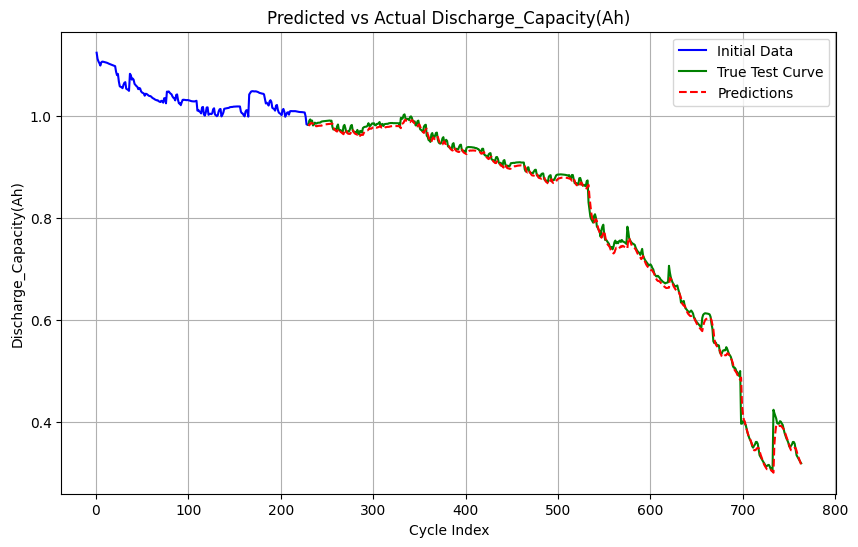


🚀 Training on CALCE Dataset 2...

Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 30s 74ms/step - loss: 0.0053 - val_loss: 0.0047 - learning_rate: 2.0000e-04
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0046 - val_loss: 0.0044 - learning_rate: 2.0000e-04
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0043 - val_loss: 0.0041 - learning_rate: 2.0000e-04
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0041 - val_loss: 0.0039 - learning_rate: 2.0000e-04
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0039 - val_loss: 0.0037 - learning_rate: 2.0000e-04
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0036 - val_loss: 0.0036 - learning_rate: 2.0000e-04
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0035 - val_loss: 0.0033 - learning_rate: 2.0000e-04
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0033 - val_loss: 0.0032 - learning_rate: 2.0000e-04
Epoch 9/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0

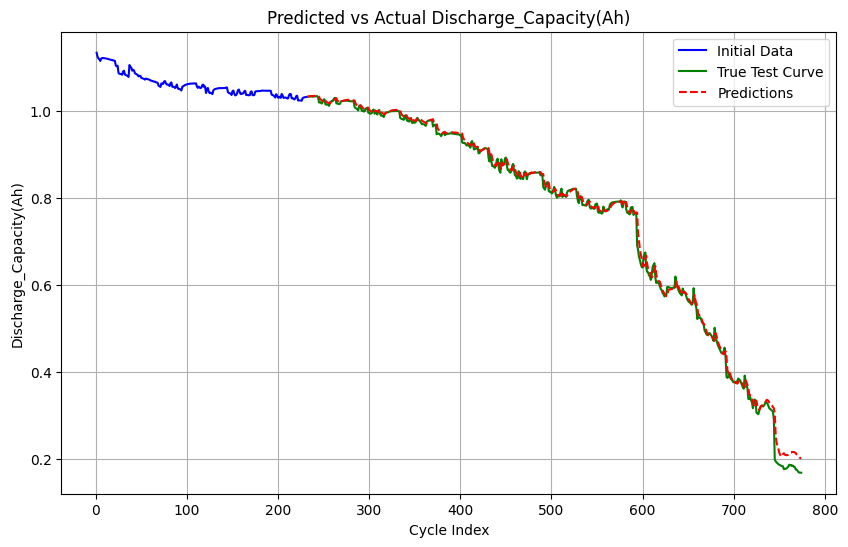


🚀 Training on CALCE Dataset 3...

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 27s 67ms/step - loss: 0.0011 - val_loss: 0.0010 - learning_rate: 2.0000e-04
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 9.8827e-04 - val_loss: 9.9995e-04 - learning_rate: 2.0000e-04
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 9.7464e-04 - val_loss: 9.8213e-04 - learning_rate: 2.0000e-04
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 9.7778e-04 - val_loss: 9.6606e-04 - learning_rate: 2.0000e-04
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 9.5435e-04 - val_loss: 9.5008e-04 - learning_rate: 2.0000e-04
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 9.3203e-04 - val_loss: 9.4251e-04 - learning_rate: 2.0000e-04
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 9.1475e-04 - val_loss: 9.2440e-04 - learning_rate: 1.0000e-04
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 9.0759e-04 - val_loss: 9.2437e-04 - learning_rate: 1.0000e-04
Epoc

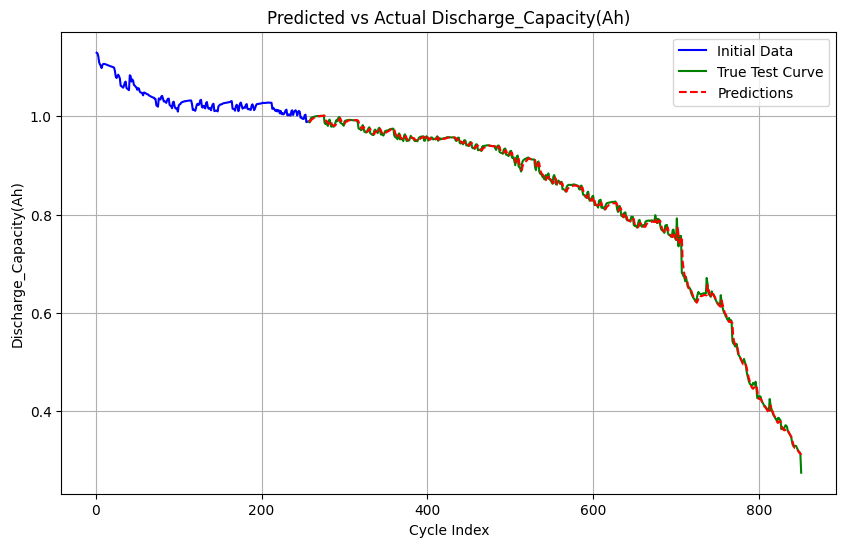


🚀 Training on CALCE Dataset 4...

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 26s 67ms/step - loss: 8.5096e-04 - val_loss: 8.4383e-04 - learning_rate: 2.0000e-04
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 8.2191e-04 - val_loss: 8.0670e-04 - learning_rate: 2.0000e-04
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 8.2419e-04 - val_loss: 7.9662e-04 - learning_rate: 2.0000e-04
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 7.9271e-04 - val_loss: 7.8505e-04 - learning_rate: 2.0000e-04
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 8.0568e-04 - val_loss: 7.6984e-04 - learning_rate: 2.0000e-04
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 7.7991e-04 - val_loss: 7.5888e-04 - learning_rate: 2.0000e-04
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 7.5908e-04 - val_loss: 7.5421e-04 - learning_rate: 1.0000e-04
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 7.5660e-04 - val_loss: 7.4918e-04 - learning_rate: 1.0000e

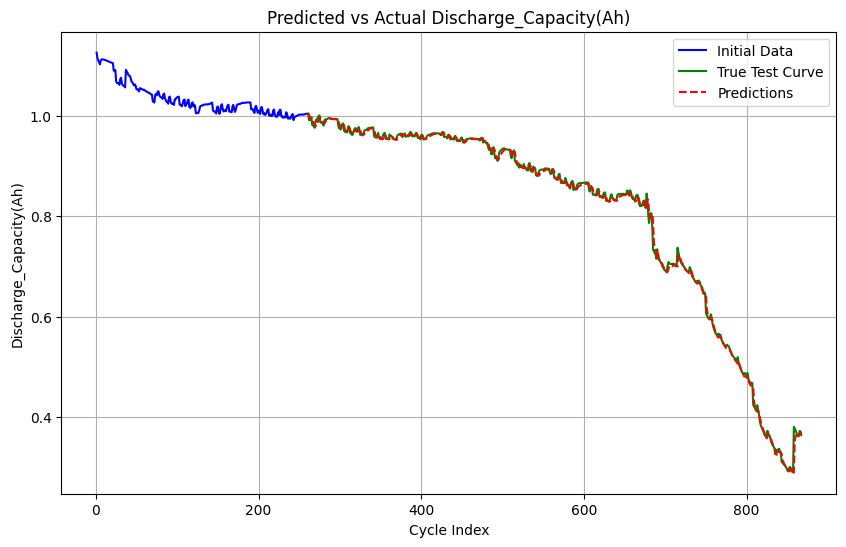

In [17]:
# 📌 Model Training Loop (TensorFlow Equivalent)
for i in range(4):
    print(f"\n🚀 Training on CALCE Dataset {i+1}...\n")
    model = Model(inputs=input_layer, outputs=output_layer)
    # Optimizer & Loss
    optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4)
    criterion = "mean_squared_error"

    # Train Model
    save_path = ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'tf_model_1_{test_and_trains[i][0]}.keras'
    train_model(
        model=model,
        train_dataset=CALCE_train_datasets[i],  # TensorFlow dataset
        val_dataset=CALCE_val_datasets[i],
        optimizer=optimizer,
        criterion=criterion,
        min_val=MIN,
        diff_val=DIFF,
        epochs=50,
        save_path=save_path
    )

    # Load Best Model
    model.load_weights(save_path)

    # Evaluate Model
    metrics = evaluate_model(model, CALCE_test_datasets[i], MIN, DIFF)
    print(f'🚀 RMSE: {metrics["RMSE"]:}, MAE: {metrics["MAE"]:}')

    # Plot Predictions
    plot_predictions(model, dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, 'Discharge_Capacity(Ah)', 30, 10)


In [14]:
# Fourier Transform-based feature embedding
def fourier_embedding(input_layer):
    return Lambda(lambda x: tf.abs(tf.signal.fft(tf.cast(x, tf.complex64))))(input_layer)

# Learnable Gated Dilation Mechanism
def gated_dilated_tcn(input_layer, nb_filters, kernel_size):
    dilation_rates = [1, 2, 4]
    branches = []
    for rate in dilation_rates:
        gate = Dense(1, activation='sigmoid')(input_layer)
        conv = Conv1D(filters=nb_filters, kernel_size=kernel_size, padding='causal', dilation_rate=rate)(input_layer)
        gated_conv = Multiply()([conv, gate])
        branches.append(gated_conv)
    return Add()(branches)

# Dual Attention Mechanism (Temporal + Spatial)
def dual_attention(input_layer, input_dim):
    query = Dense(input_dim)(input_layer)
    key = Dense(input_dim)(input_layer)
    value = Dense(input_dim)(input_layer)
    attention_scores = Lambda(lambda x: tf.matmul(x[0], x[1], transpose_b=True))([query, key])
    attention_weights = Softmax()(attention_scores)
    spatial_attention = Multiply()([value, attention_weights])
    temporal_attention = Conv1D(filters=input_dim, kernel_size=1, activation='sigmoid')(input_layer)
    return Multiply()([spatial_attention, temporal_attention])

# Uncertainty-Aware MC Dropout
def mc_dropout(rate=0.2):
    return Dropout(rate)

def build_model(input_shape):
    input_layer = Input(shape=input_shape)
    embedded_features = fourier_embedding(input_layer)
    attention_output = dual_attention(embedded_features, input_shape[-1])
    tcn_output = gated_dilated_tcn(attention_output, nb_filters=32, kernel_size=3)
    norm_output = LayerNormalization()(tcn_output)
   
    # Memory-Augmented GRU
    gru_layer = GRU(64, activation='relu', return_sequences=True)(norm_output)
    memory_gate = Dense(64, activation='sigmoid')(gru_layer)
    memory_output = Multiply()([gru_layer, memory_gate])
   
    flattened_output = Flatten()(memory_output)  # <---- Added Flatten Layer

    # Dense layers with MC Dropout
    dense1 = Dense(32, activation='relu', kernel_regularizer=l2(0.001))(flattened_output)
    dropout1 = mc_dropout()(dense1)
    dense2 = Dense(16, activation='relu', kernel_regularizer=l2(0.001))(dropout1)
    dropout2 = mc_dropout()(dense2)
    output_layer = Dense(1, activation='linear')(dropout2)
   
    model = Model(inputs=input_layer, outputs=output_layer)
    return model


🚀 Training on CALCE Dataset 35...

Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 35s 84ms/step - loss: 0.1610 - val_loss: 0.0216 - learning_rate: 0.0050
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0388 - val_loss: 0.0155 - learning_rate: 0.0050
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0273 - val_loss: 0.0122 - learning_rate: 0.0050
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0240 - val_loss: 0.0098 - learning_rate: 0.0050
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0198 - val_loss: 0.0075 - learning_rate: 0.0050
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0177 - val_loss: 0.0086 - learning_rate: 0.0050
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0150 - val_loss: 0.0051 - learning_rate: 0.0050
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0132 - val_loss: 0.0048 - learning_rate: 0.0050
Epoch 9/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0132 - val_loss: 0.0058 - lear

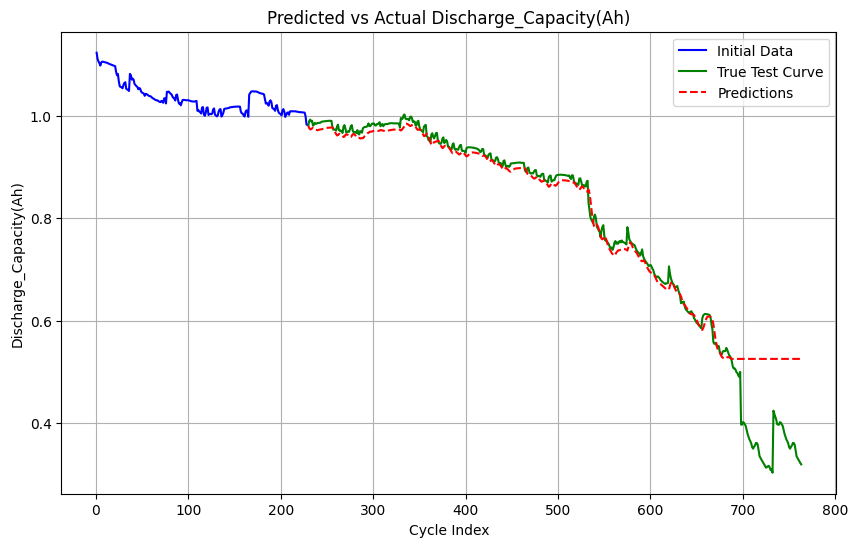


🚀 Training on CALCE Dataset 36...

Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - loss: 0.1678 - val_loss: 0.0231 - learning_rate: 0.0050
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0410 - val_loss: 0.0245 - learning_rate: 0.0050
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0317 - val_loss: 0.0127 - learning_rate: 0.0050
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0222 - val_loss: 0.0120 - learning_rate: 0.0050
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0193 - val_loss: 0.0084 - learning_rate: 0.0050
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0161 - val_loss: 0.0060 - learning_rate: 0.0050
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0145 - val_loss: 0.0053 - learning_rate: 0.0050
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0118 - val_loss: 0.0039 - learning_rate: 0.0050
Epoch 9/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0103 - val_loss: 0.0035 - lear

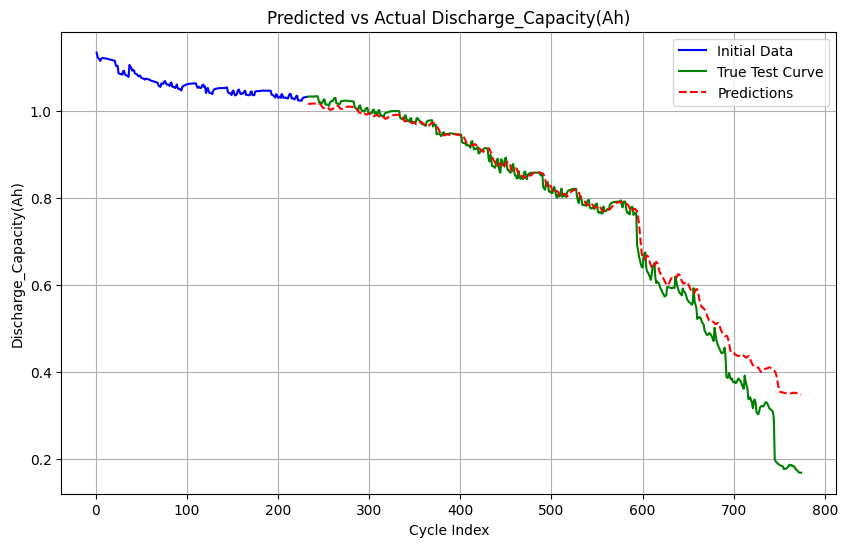


🚀 Training on CALCE Dataset 37...

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - loss: 0.2653 - val_loss: 0.0282 - learning_rate: 0.0050
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0524 - val_loss: 0.0276 - learning_rate: 0.0050
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0413 - val_loss: 0.0246 - learning_rate: 0.0050
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0365 - val_loss: 0.0157 - learning_rate: 0.0050
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0270 - val_loss: 0.0087 - learning_rate: 0.0050
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0202 - val_loss: 0.0082 - learning_rate: 0.0050
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0165 - val_loss: 0.0058 - learning_rate: 0.0050
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0121 - val_loss: 0.0054 - learning_rate: 0.0050
Epoch 9/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0107 - val_loss: 0.0042 - lear

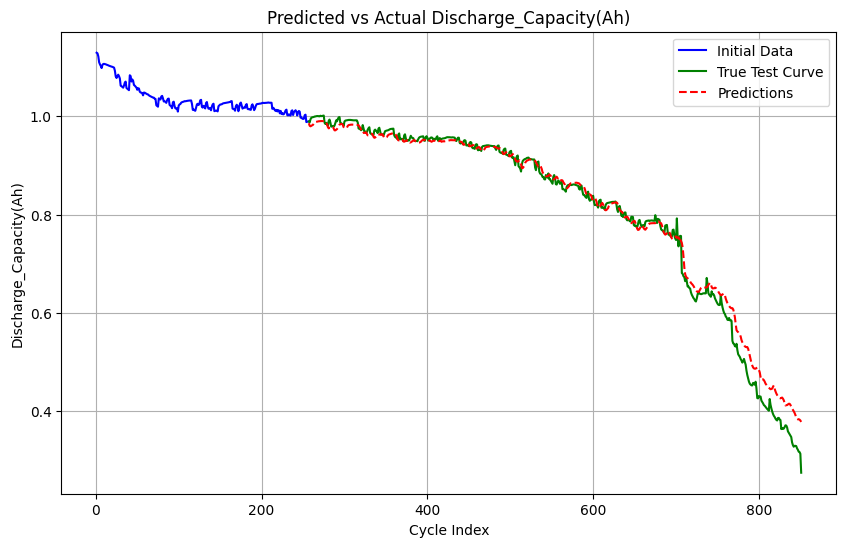


🚀 Training on CALCE Dataset 38...

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - loss: 0.2466 - val_loss: 0.0415 - learning_rate: 0.0050
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0550 - val_loss: 0.0222 - learning_rate: 0.0050
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0371 - val_loss: 0.0139 - learning_rate: 0.0050
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0292 - val_loss: 0.0109 - learning_rate: 0.0050
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0247 - val_loss: 0.0086 - learning_rate: 0.0050
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0213 - val_loss: 0.0068 - learning_rate: 0.0050
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0177 - val_loss: 0.0062 - learning_rate: 0.0050
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0160 - val_loss: 0.0084 - learning_rate: 0.0050
Epoch 9/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0152 - val_loss: 0.0047 - lear

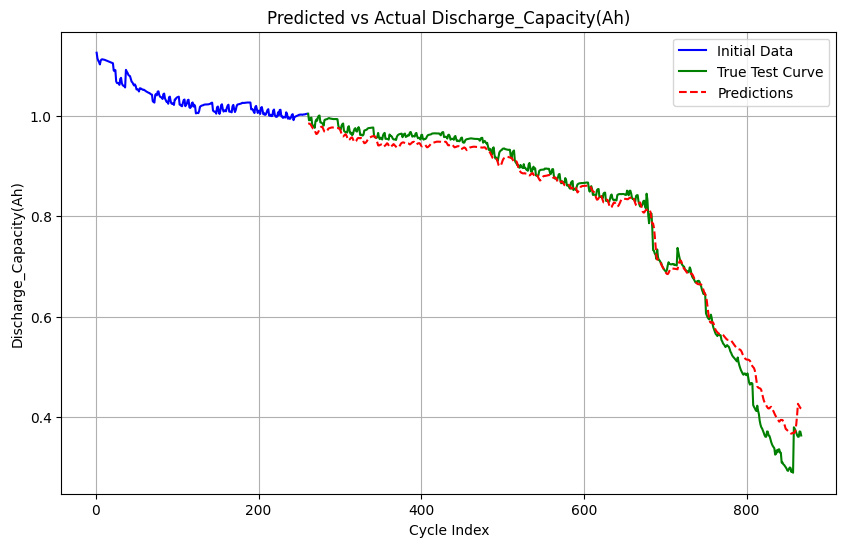

In [16]:
# 📌 Model Training Loop (TensorFlow Equivalent)
for i in range(4):
    print(f"\n🚀 Training on CALCE Dataset {test_and_trains[i][0]}...\n")
    input_shape = (trainX.shape[1], 1) 
    model = build_model(input_shape)
    # Optimizer & Loss
    optimizer = tf.keras.optimizers.Adam(learning_rate=5e-3)
    criterion = "mean_squared_error"

    # Train Model
    save_path = ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'tf_model_2_{test_and_trains[i][0]}.keras'
    train_model(
        model=model,
        train_dataset=CALCE_train_datasets[i],  # TensorFlow dataset
        val_dataset=CALCE_val_datasets[i],
        optimizer=optimizer,
        criterion=criterion,
        min_val=MIN,
        diff_val=DIFF,
        epochs=50,
        save_path=save_path
    )

    # Load Best Model
    model.load_weights(save_path)

    # Evaluate Model
    metrics = evaluate_model(model, CALCE_test_datasets[i], MIN, DIFF)
    print(f'🚀 RMSE: {metrics["RMSE"]:}, MAE: {metrics["MAE"]:}')

    # Plot Predictions
    plot_predictions(model, dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, 'Discharge_Capacity(Ah)', 30, 5)
